In [1]:
import numpy as np

import os

import xarray as xr

import glob

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

import pandas as pd

from matplotlib.colors import BoundaryNorm

import matplotlib.colors as mcolors

import dask.array as da

import pickle

from scipy.stats import t

import matplotlib.ticker as ticker

from pathlib import Path

import cartopy.crs as ccrs

import cartopy.feature as cfeature

import seaborn as sns

### buoyancy -> virtual temperature 

In [2]:
data_dir = Path("/data/rong3/annie/completed_buoyancy_arrays_virtual_temp_15lst/")

blc_files = sorted(glob.glob(str(data_dir / "blc_*.npz")))

blt_files = sorted(glob.glob(str(data_dir / "blt_*.npz")))

def concatenate_arrays(file_list, key):
    
    arrays = [np.load(f)[key] for f in file_list]  # Load arrays using the correct key
    
    return np.concatenate(arrays, axis=0)  # Concatenate along the first dimension

blc = concatenate_arrays(blc_files, key='all_blc')

blt = concatenate_arrays(blt_files, key='all_blt')

blc.shape, blt.shape

((306, 37, 41), (306, 37, 41))

### buoyancy -> non-virtual temperature

In [3]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [7]:
backup_dir = Path.home() / "split_SGP_domain_arrays_15lst/2001-2002"

backup_dir.mkdir(parents=True, exist_ok=True)

file_path = backup_dir / "arrays_for_buoyancy_2001-2002.npz"

data = np.load(file_path, mmap_mode='r')

lats = data['lats']

lons = data['lons']

In [12]:
# base_dir = Path.home() / "split_SGP_domain_arrays_15lst"

# all_times = []

# for sub in sorted(base_dir.iterdir()):
    
#     if sub.is_dir():
        
#         # find the .npz file inside the folder
#         npz_files = sorted(sub.glob("*.npz"))
        
#         if len(npz_files) == 0:
            
#             continue
        
#         # assume one NPZ per folder
        
#         fp = npz_files[0]
        
#         data = np.load(fp, mmap_mode='r')
        
#         # extract times array
#         all_times.append(data['times'])

# # concatenate everything
# times = np.concatenate(all_times)

# # AND SORT the combined array
# times = np.sort(times)

# print(times.shape)

backup_dir = os.path.expanduser("~/split_SGP_domain_arrays_15lst")

folder_name = "2001-2002"

file_path = os.path.join(
    
    backup_dir,
    
    folder_name,
    
    f"arrays_for_buoyancy_{folder_name}.npz"
)

# Load only the 'times' variable

with np.load(file_path, mmap_mode='r') as data:
    
    times = data["times"]

print("Shape:", times.shape)

Shape: (306,)


In [15]:
T, Y, X = np.meshgrid(times, lats, lons, indexing="ij")

# Flatten everything

flat_times = T.ravel()

flat_lats  = Y.ravel()

flat_lons  = X.ravel()

flat_blt   = blt.ravel()

flat_blc   = blc.ravel()

In [16]:
buoyancy = pd.DataFrame({
    
    "time": flat_times,
    
    "lat": flat_lats,
    
    "lon": flat_lons,
    
    "blt": flat_blt,
    
    "blc": flat_blc
})

In [17]:
buoyancy["time"] = pd.to_datetime(buoyancy["time"])

buoyancy["date"] = buoyancy["time"].dt.date

In [18]:
buoyancy = buoyancy.rename(columns={
    
    "blt": "blt_vt",
    
    "blc": "blc_vt"
})

In [19]:
buoyancy = buoyancy.rename(columns={
    
    "lat": "latitude",
    
    "lon": "longitude"
})

In [20]:
master_sub = master[["date", "latitude", "longitude", "blt", "blc","APE", "dryape", "wetape", "drycoupling", "wetcoupling","daily_precip"]]

master_sub["date"] = pd.to_datetime(master_sub["date"]).dt.date

buoyancy["date"]   = pd.to_datetime(buoyancy["date"]).dt.date

merged = buoyancy.merge(
    
    master_sub,
    
    how="inner",
    
    on=["date", "latitude", "longitude"]
)

/tmp/ipykernel_59717/1354885421.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_sub["date"] = pd.to_datetime(master_sub["date"]).dt.date


In [26]:
merged['br_vt'] = merged['blt_vt'] + merged['blc_vt']

merged['br'] = merged['blt'] + merged['blc']

In [27]:
merged['br_diff'] = merged['br_vt'] - merged['br']

In [35]:
#2002-09-30T12:00:00.000000000 31.25 -96.5

check = merged[
    
    (merged["time"] == "2002-09-26T15:00:00") &
    
    (merged["latitude"] == 30.0) &
    
    (merged["longitude"] == -95.25)
]

check['br_vt'], check['br']

#br virt = -209.904746, br = -388.93836

(458132   -218.868157
 Name: br_vt, dtype: float64,
 458132   -388.93836
 Name: br, dtype: float64)

In [36]:
print(merged.shape)

clean = merged.dropna(subset=["blt_vt", "blc_vt"])

print(clean.shape)

(464202, 17)
(464202, 17)


In [37]:
# x = clean["blc_vt"]

# y = clean["blt_vt"]

# corr, pval = pearsonr(x, y)

# print("Pearson r:", corr)

# print("p-value:", pval)

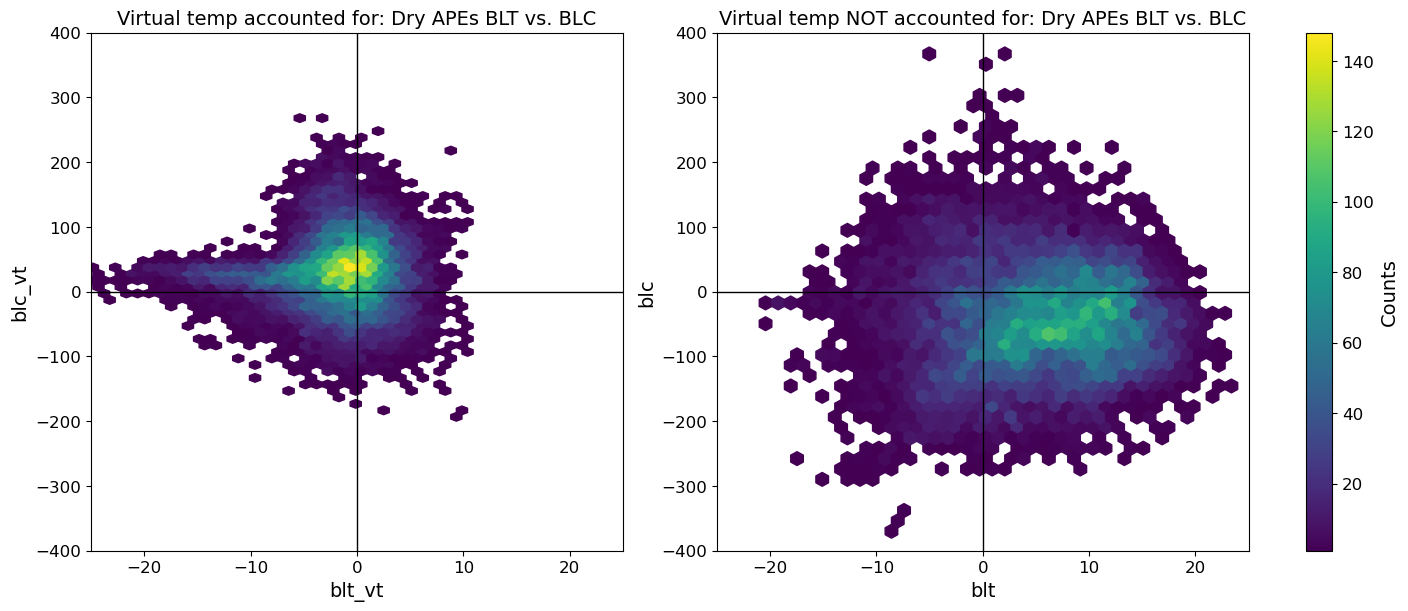

In [38]:
df = clean[clean["dryape"] == True]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# --- First hexbin (left) ---

hb1 = ax1.hexbin(
    
    df["blt_vt"],
    
    df["blc_vt"],
    
    gridsize=40,
    
    mincnt=1,
    
    cmap="viridis"
)

ax1.set_xlabel("blt_vt", fontsize=14)

ax1.set_ylabel("blc_vt", fontsize=14)

ax1.set_xlim(-25, 25)

ax1.set_ylim(-400, 400)

ax1.set_title("Virtual temp accounted for: Dry APEs BLT vs. BLC", fontsize=14)

ax1.tick_params(axis="both", labelsize=12)

ax1.axhline(0, color="black", linewidth=1)

ax1.axvline(0, color="black", linewidth=1)

# --- Second hexbin (right), using SAME normalization ---
hb2 = ax2.hexbin(
    
    df["blt"],
    
    df["blc"],
    
    gridsize=40,
    
    mincnt=1,
    
    cmap="viridis",
    
    norm=hb1.norm
)

ax2.set_xlabel("blt", fontsize=14)

ax2.set_ylabel("blc", fontsize=14)

ax2.set_xlim(-25, 25)

ax2.set_ylim(-400, 400)

ax2.set_title("Virtual temp NOT accounted for: Dry APEs BLT vs. BLC", fontsize=14)

ax2.tick_params(axis="both", labelsize=12)

ax2.axhline(0, color="black", linewidth=1)

ax2.axvline(0, color="black", linewidth=1)

# --- Shared colorbar ---

cbar = fig.colorbar(hb1, ax=[ax1, ax2], label="Counts")

cbar.ax.tick_params(labelsize=12)

cbar.set_label("Counts", fontsize=14)

plt.show()

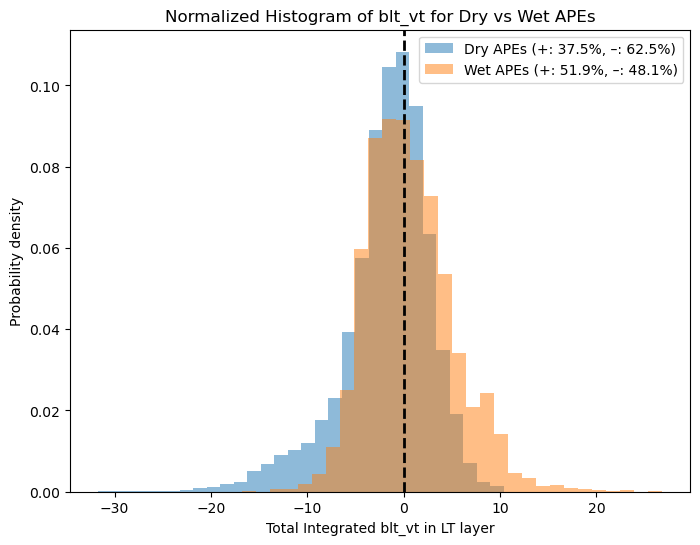

In [55]:
dry = merged[merged['dryape'] == True]

wet = merged[merged['wetape'] == True]

var = 'blt_vt'

# Compute percentages

dry_pos = (dry[var] > 0).mean() * 100

dry_neg = (dry[var] < 0).mean() * 100

wet_pos = (wet[var] > 0).mean() * 100

wet_neg = (wet[var] < 0).mean() * 100

plt.figure(figsize=(8,6))

plt.hist(
    dry[var], bins=30, alpha=0.5, density=True,
    label=f"Dry APEs (+: {dry_pos:.1f}%, –: {dry_neg:.1f}%)"
)

plt.hist(
    wet[var], bins=30, alpha=0.5, density=True,
    label=f"Wet APEs (+: {wet_pos:.1f}%, –: {wet_neg:.1f}%)"
)

# Add vertical line at x = 0
plt.axvline(0, color='black', linestyle='--', linewidth=2)

plt.xlabel('Total Integrated {} in LT layer'.format(var))

plt.ylabel('Probability density')

plt.title('Normalized Histogram of {} for Dry vs Wet APEs'.format(var))

plt.legend()

plt.show()

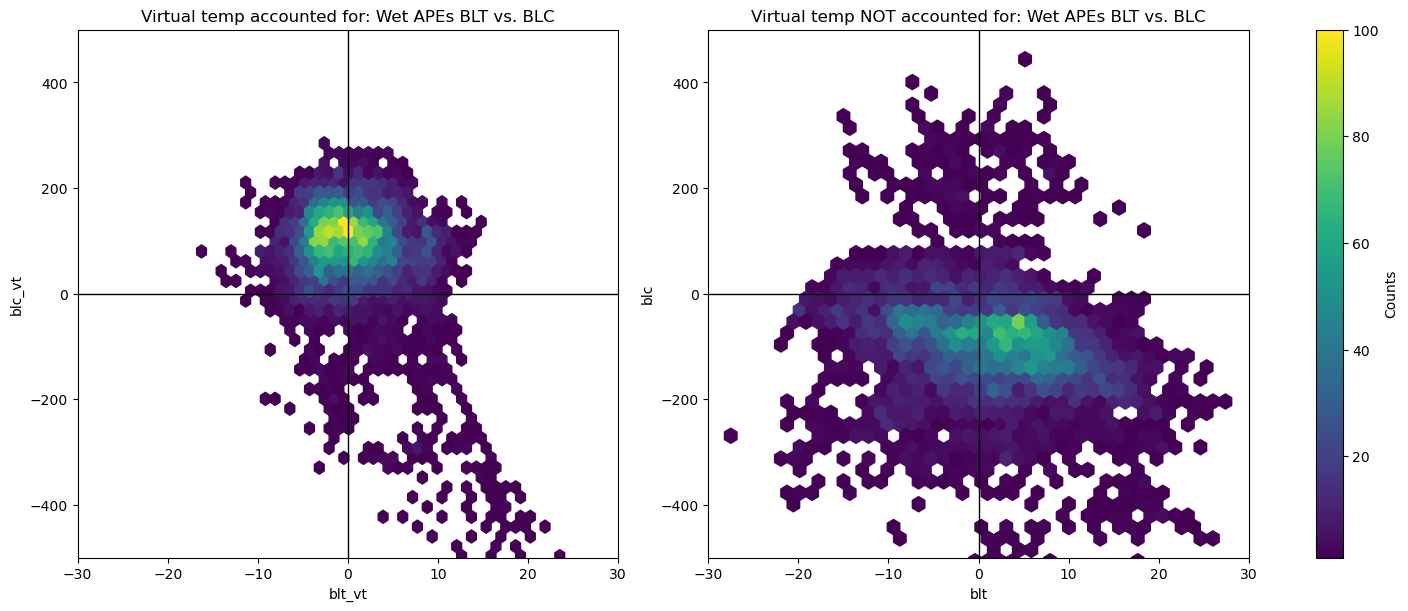

In [40]:
df = clean[clean["wetape"] == True]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)  # <-- use constrained_layout

# --- First hexbin (left) ---
hb1 = ax1.hexbin(
    df["blt_vt"],
    df["blc_vt"],
    gridsize=40,
    mincnt=1,
    cmap="viridis"
)
ax1.set_xlabel("blt_vt")
ax1.set_xlim(-30, 30)
ax1.set_ylim(-500, 500)
ax1.set_ylabel("blc_vt")
ax1.set_title("Virtual temp accounted for: Wet APEs BLT vs. BLC")
ax1.axhline(0, color="black", linewidth=1)
ax1.axvline(0, color="black", linewidth=1)

# --- Second hexbin (right), using SAME normalization ---
hb2 = ax2.hexbin(
    df["blt"],
    df["blc"],
    gridsize=40,
    mincnt=1,
    cmap="viridis",
    norm=hb1.norm
)

ax2.set_xlabel("blt")

ax2.set_xlim(-30, 30)

ax2.set_ylim(-500, 500)

ax2.set_ylabel("blc")

ax2.set_title("Virtual temp NOT accounted for: Wet APEs BLT vs. BLC")

ax2.axhline(0, color="black", linewidth=1)

ax2.axvline(0, color="black", linewidth=1)

# --- Shared colorbar ---

cbar = fig.colorbar(hb1, ax=[ax1, ax2], label="Counts")

plt.show()


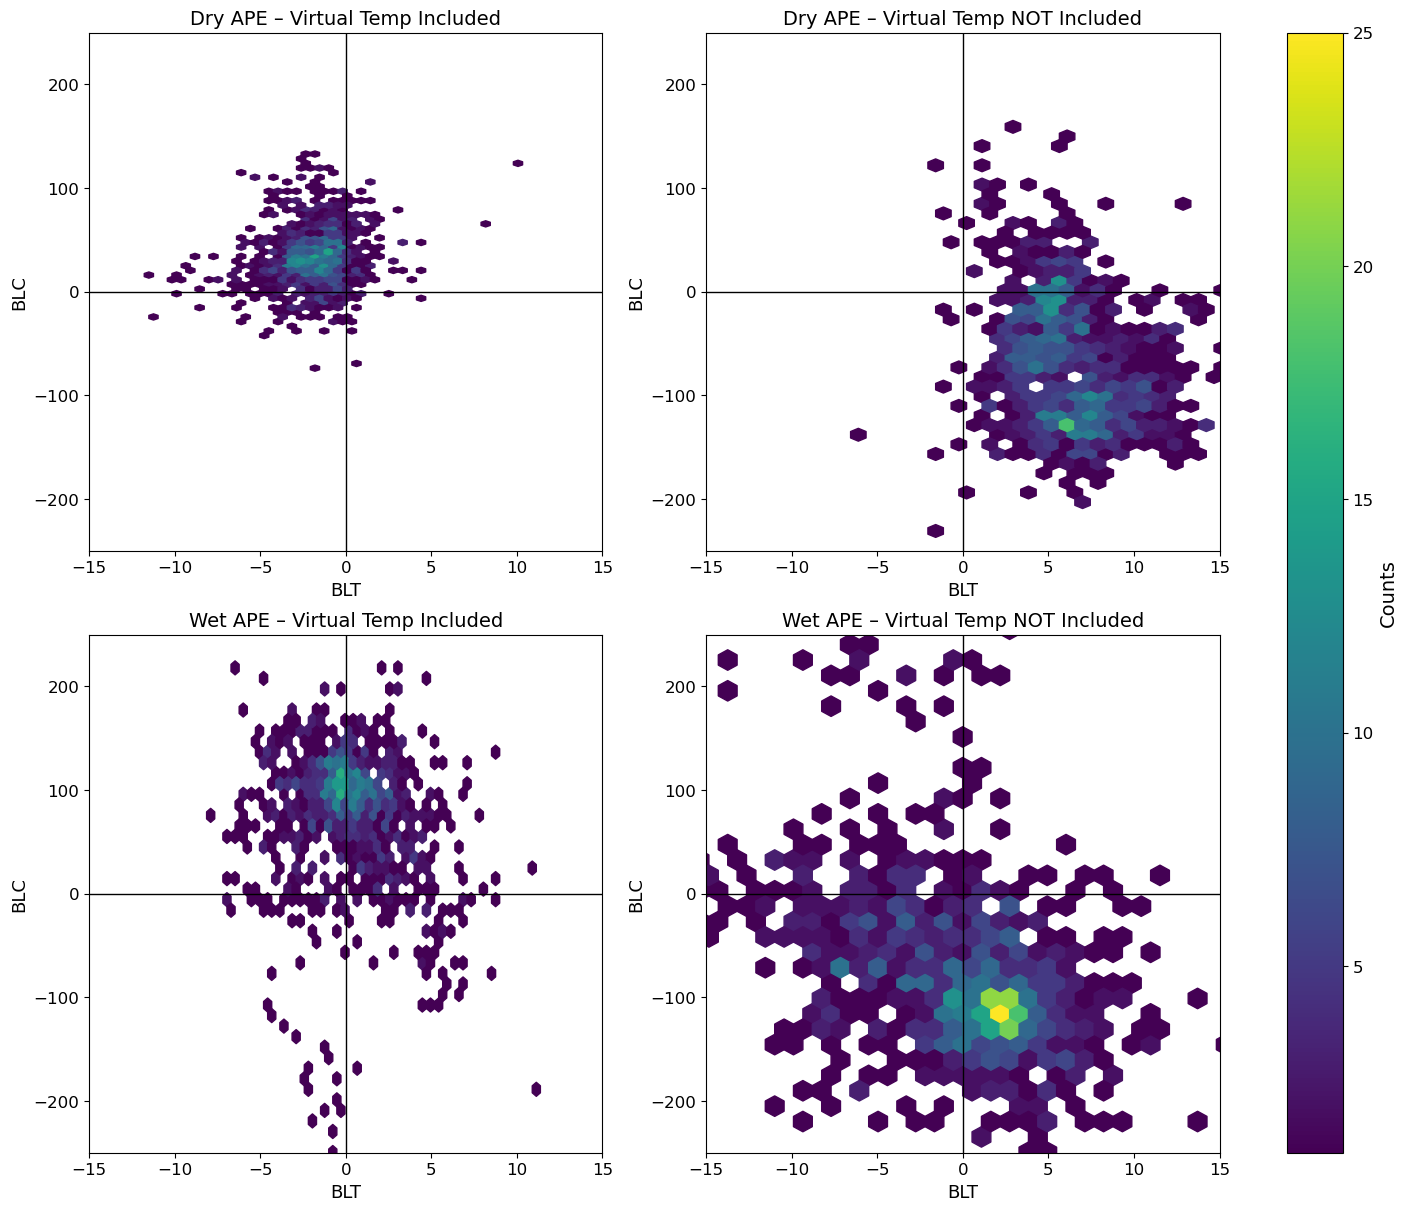

In [41]:
# ---------------------------------------------------
# 1. Drop rows with NaN in relevant columns
# ---------------------------------------------------

clean = merged.dropna(subset=["blt_vt", "blc_vt", "blt", "blc"])

# ---------------------------------------------------
# 2. Create dry/wet subsets
# ---------------------------------------------------

df_dry = clean[clean["dryape"] == True]

df_wet = clean[clean["wetape"] == True]

# ---------------------------------------------------
# 3. Group by gridpoint and compute means
# ---------------------------------------------------

def group_df(df):
    
    return (
        
        df.groupby(["latitude", "longitude"], as_index=False)
          [["blt_vt", "blc_vt", "blt", "blc"]]
          .mean()
    )

g_dry = group_df(df_dry)

g_wet = group_df(df_wet)

# ---------------------------------------------------
# 4. Prepare figure (4 panels)
# ---------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# For easier indexing
(ax11, ax12), (ax21, ax22) = axes

# ---------------------------------------------------
# Plot specs
# ---------------------------------------------------
xlims = (-15, 15)
ylims = (-250, 250)

# ---------------------------------------------------
# 5. First: plot all four hexbins BUT capture the min/max counts
#    so we can apply a shared color normalization
# ---------------------------------------------------

hexbins = []

# --- Dry APE, VT included ---
hb1 = ax11.hexbin(
    g_dry["blt_vt"], g_dry["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis"
)
hexbins.append(hb1)

# --- Dry APE, VT NOT included ---
hb2 = ax12.hexbin(
    g_dry["blt"], g_dry["blc"],
    gridsize=40, mincnt=1, cmap="viridis"
)
hexbins.append(hb2)

# --- Wet APE, VT included ---
hb3 = ax21.hexbin(
    g_wet["blt_vt"], g_wet["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis"
)
hexbins.append(hb3)

# --- Wet APE, VT NOT included ---
hb4 = ax22.hexbin(
    g_wet["blt"], g_wet["blc"],
    gridsize=40, mincnt=1, cmap="viridis"
)
hexbins.append(hb4)

# ---------------------------------------------------
# 6. Apply SHARED color normalization across all panels
# ---------------------------------------------------
vmin = min(h.get_array().min() for h in hexbins)
vmax = max(h.get_array().max() for h in hexbins)

for hb in hexbins:
    hb.set_clim(vmin, vmax)

# ---------------------------------------------------
# 7. Axis formatting helper
# ---------------------------------------------------
def format_ax(ax, title):
    ax.set_title(title, fontsize=14)
    ax.set_xlim(*xlims)
    ax.set_ylim(*ylims)
    ax.set_xlabel("BLT", fontsize=13)
    ax.set_ylabel("BLC", fontsize=13)
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.tick_params(axis="both", labelsize=12)

# ---------------------------------------------------
# 8. Add titles + formatting
# ---------------------------------------------------
format_ax(ax11, "Dry APE – Virtual Temp Included")
format_ax(ax12, "Dry APE – Virtual Temp NOT Included")
format_ax(ax21, "Wet APE – Virtual Temp Included")
format_ax(ax22, "Wet APE – Virtual Temp NOT Included")

# ---------------------------------------------------
# 9. Single shared colorbar
# ---------------------------------------------------
cbar = fig.colorbar(hexbins[0], ax=axes.ravel().tolist(), label="Counts")

cbar.ax.tick_params(labelsize=12)

cbar.set_label("Counts", fontsize=14)

plt.show()


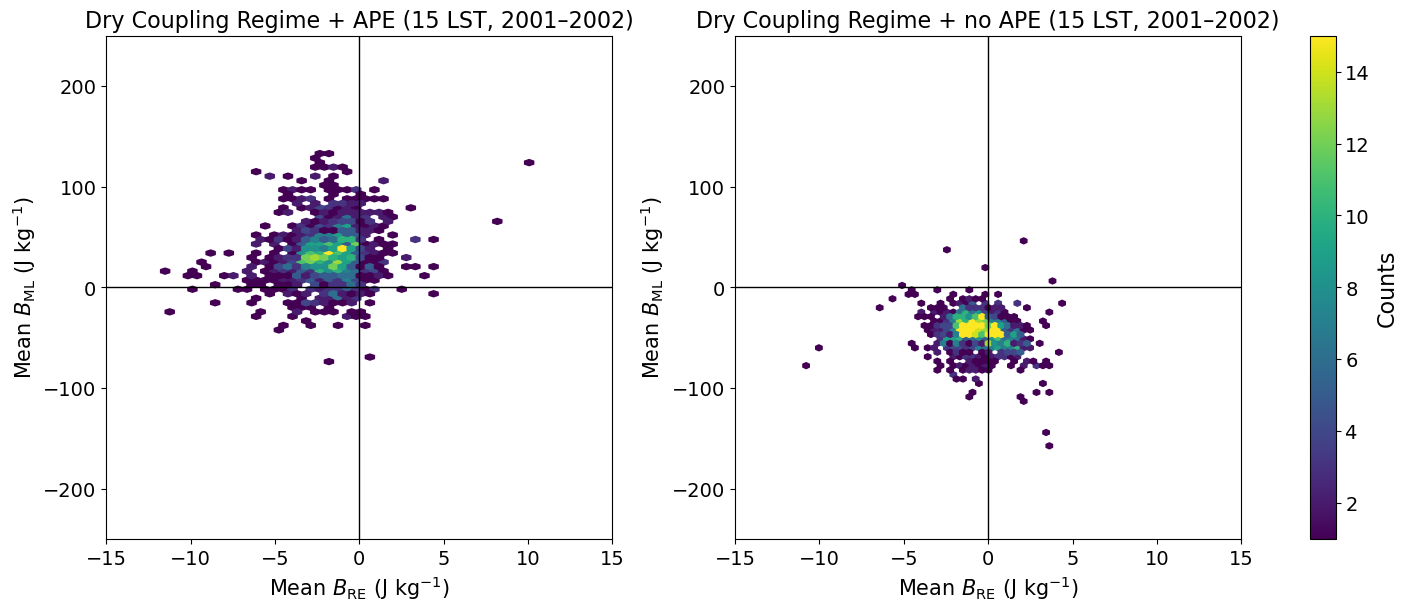

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Drop rows with NaN in relevant columns
# ---------------------------------------------------
clean = merged.dropna(subset=["blt_vt", "blc_vt", "dryape", "drycoupling"])

# ---------------------------------------------------
# 2. Filter to ONLY drycoupling = True
# ---------------------------------------------------
df = clean[clean["drycoupling"] == True]

# ---------------------------------------------------
# 3. Create dryAPE TRUE and FALSE subsets
# ---------------------------------------------------
df_dryape_true  = df[df["dryape"] == True]
df_dryape_false = df[df["dryape"] == False]

# ---------------------------------------------------
# 4. Group by gridpoint and compute BLT/BLC means
# ---------------------------------------------------
def group_df(df):
    return (
        df.groupby(["latitude", "longitude"], as_index=False)[["blt_vt", "blc_vt"]]
          .mean()
    )

g_true  = group_df(df_dryape_true)
g_false = group_df(df_dryape_false)

# ---------------------------------------------------
# 5. Create figure with 2 side-by-side panels
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ax1, ax2 = axes

# ---------------------------------------------------
# Plot limits
# ---------------------------------------------------
xlims = (-15, 15)
ylims = (-250, 250)

# ---------------------------------------------------
# 6. Make the hexbins
# ---------------------------------------------------
hb1 = ax1.hexbin(
    g_true["blt_vt"], g_true["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis"
)

hb2 = ax2.hexbin(
    g_false["blt_vt"], g_false["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis",
    norm=hb1.norm  # shared normalization
)

# ---------------------------------------------------
# 7. Formatting helper
# ---------------------------------------------------
def format_ax(ax, title):
    ax.set_title(title, fontsize=16)  # increased from 14 → 16

    ax.set_xlim(*xlims)
    ax.set_ylim(*ylims)

    ax.set_xlabel(r"Mean $B_{\mathrm{RE}}$ (J kg$^{-1}$)", fontsize=15)
    ax.set_ylabel(r"Mean $B_{\mathrm{ML}}$ (J kg$^{-1}$)", fontsize=15)

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)

    ax.tick_params(axis="both", labelsize=14)  # increased from 12 → 14

format_ax(ax1, "Dry Coupling Regime + APE (15 LST, 2001–2002)")
format_ax(ax2, "Dry Coupling Regime + no APE (15 LST, 2001–2002)")

# ---------------------------------------------------
# 8. Shared colorbar
# ---------------------------------------------------
cbar = fig.colorbar(hb1, ax=axes, label="Counts")
cbar.ax.tick_params(labelsize=14)  # 12 → 14
cbar.set_label("Counts", fontsize=16)  # 14 → 16

plt.show()


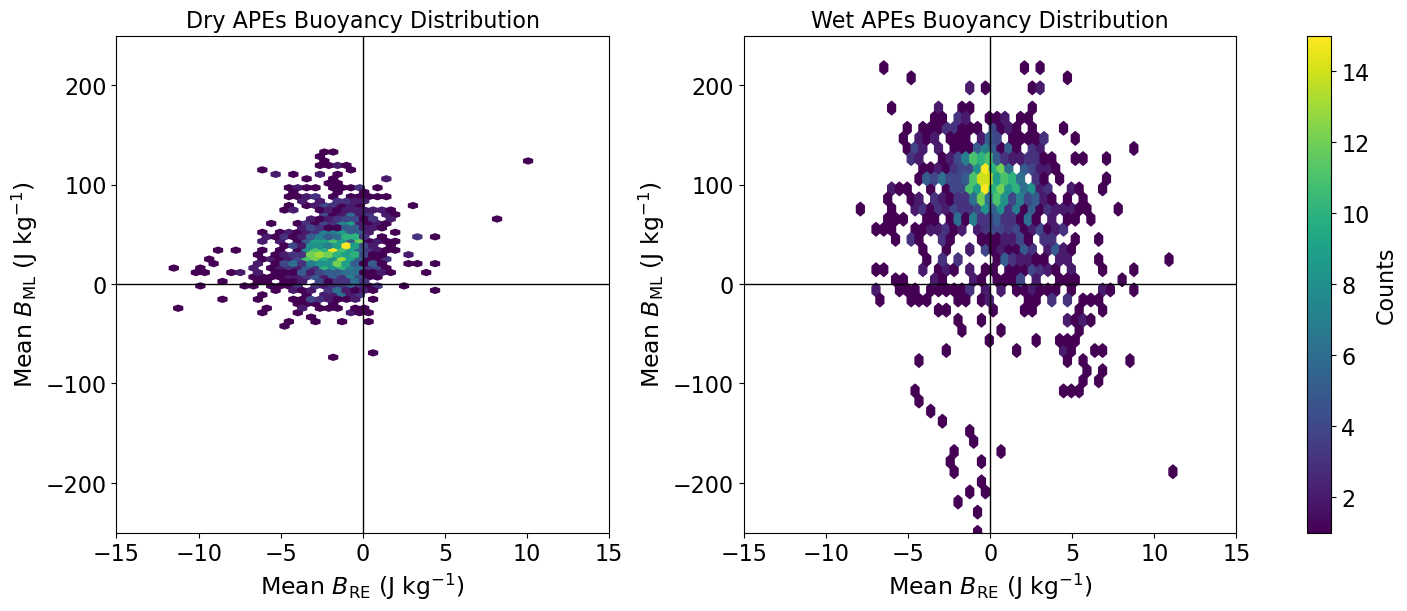

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Drop rows with NaN in relevant columns
# ---------------------------------------------------
clean = merged.dropna(subset=["blt_vt", "blc_vt", "dryape", "wetape"])

# ---------------------------------------------------
# 2. Filter subsets
# ---------------------------------------------------
df_dry = clean[clean["dryape"] == True]
df_wet = clean[clean["wetape"] == True]

# ---------------------------------------------------
# 3. Group by gridpoint and compute BLT/BLC means
# ---------------------------------------------------
def group_df(df):
    return (
        df.groupby(["latitude", "longitude"], as_index=False)[["blt_vt", "blc_vt"]]
          .mean()
    )

g_dry = group_df(df_dry)
g_wet = group_df(df_wet)

# ---------------------------------------------------
# 4. Create figure
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
ax1, ax2 = axes

# ---------------------------------------------------
# Plot limits
# ---------------------------------------------------
xlims = (-15, 15)
ylims = (-250, 250)

# ---------------------------------------------------
# 5. Hexbin plots
# ---------------------------------------------------
hb1 = ax1.hexbin(
    g_dry["blt_vt"], g_dry["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis"
)

hb2 = ax2.hexbin(
    g_wet["blt_vt"], g_wet["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis",
    norm=hb1.norm
)

# ---------------------------------------------------
# 6. Formatting helper
# ---------------------------------------------------
def format_ax(ax, title):
    ax.set_title(title, fontsize=16)

    ax.set_xlim(*xlims)
    ax.set_ylim(*ylims)

    ax.set_xlabel(r"Mean $B_{\mathrm{RE}}$ (J kg$^{-1}$)", fontsize=17)
    ax.set_ylabel(r"Mean $B_{\mathrm{ML}}$ (J kg$^{-1}$)", fontsize=17)

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)

    ax.tick_params(axis="both", labelsize=16)

format_ax(ax1, "Dry APEs Buoyancy Distribution")
format_ax(ax2, "Wet APEs Buoyancy Distribution")

# ---------------------------------------------------
# 7. Shared colorbar
# ---------------------------------------------------
cbar = fig.colorbar(hb1, ax=axes, label="Counts")
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Counts", fontsize=16)

plt.show()


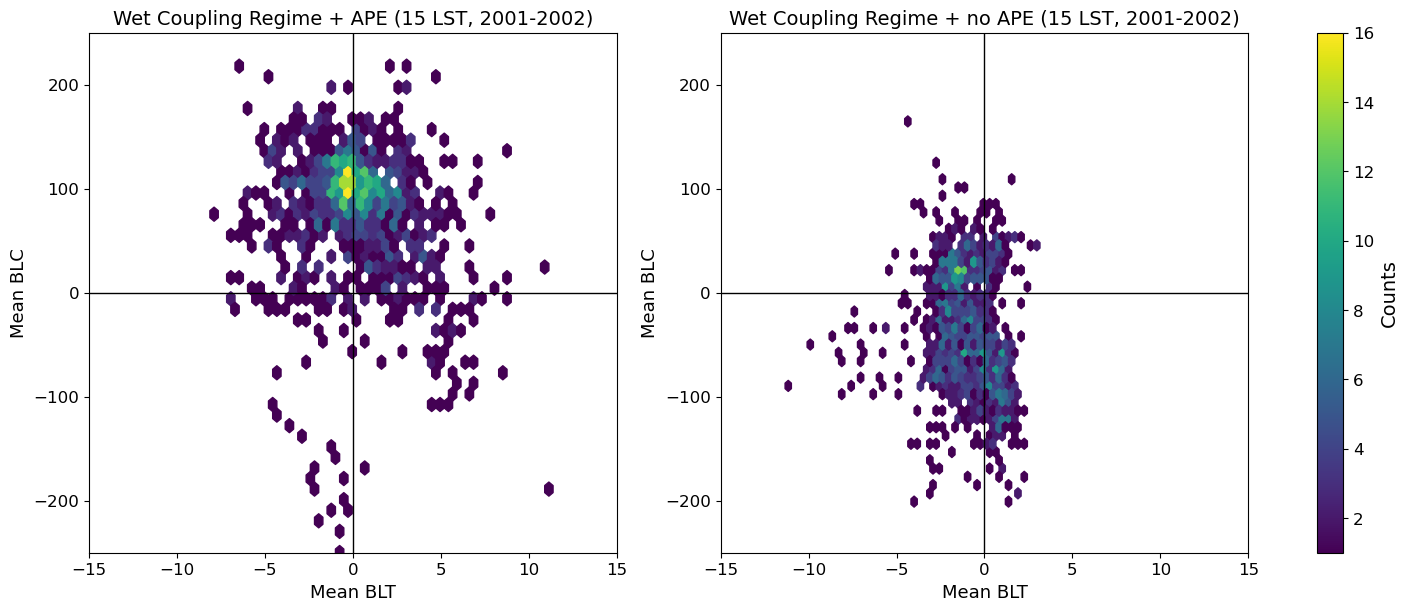

In [48]:
# ---------------------------------------------------

# 1. Drop rows with NaN in relevant columns

# ---------------------------------------------------

clean = merged.dropna(subset=["blt_vt", "blc_vt", "wetape", "wetcoupling"])

# ---------------------------------------------------
# 2. Filter to ONLY wetcoupling = True
# ---------------------------------------------------
df = clean[clean["wetcoupling"] == True]

# ---------------------------------------------------
# 3. Create wetAPE TRUE and FALSE subsets
# ---------------------------------------------------
df_wetape_true  = df[df["wetape"] == True]

df_wetape_false = df[df["wetape"] == False]

# ---------------------------------------------------
# 4. Group by gridpoint and compute BLT/BLC means
# ---------------------------------------------------
def group_df(df):
    return (
        df.groupby(["latitude", "longitude"], as_index=False)[["blt_vt", "blc_vt"]]
          .mean()
    )

g_true  = group_df(df_wetape_true)
g_false = group_df(df_wetape_false)

# ---------------------------------------------------
# 5. Create figure with 2 side-by-side panels
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ax1, ax2 = axes

# ---------------------------------------------------
# Plot limits
# ---------------------------------------------------
xlims = (-15, 15)
ylims = (-250, 250)

# ---------------------------------------------------
# 6. Make the hexbins
# ---------------------------------------------------
hb1 = ax1.hexbin(
    g_true["blt_vt"], g_true["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis"
)

hb2 = ax2.hexbin(
    g_false["blt_vt"], g_false["blc_vt"],
    gridsize=40, mincnt=1, cmap="viridis",
    norm=hb1.norm  # shared normalization
)

# ---------------------------------------------------
# 7. Formatting helper
# ---------------------------------------------------
def format_ax(ax, title):
    ax.set_title(title, fontsize=14)
    ax.set_xlim(*xlims)
    ax.set_ylim(*ylims)
    ax.set_xlabel("Mean BLT", fontsize=13)
    ax.set_ylabel("Mean BLC", fontsize=13)
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.tick_params(axis="both", labelsize=12)

format_ax(ax1,  "Wet Coupling Regime + APE (15 LST, 2001-2002)")

format_ax(ax2,  "Wet Coupling Regime + no APE (15 LST, 2001-2002)")

# ---------------------------------------------------
# 8. Shared colorbar
# ---------------------------------------------------
cbar = fig.colorbar(hb1, ax=axes, label="Counts")

cbar.ax.tick_params(labelsize=12)

cbar.set_label("Counts", fontsize=14)

plt.show()


In [56]:
sample = df_dry[df_dry['br_vt'] < 0]

sample_2001_2002 = (
    
    sample[(sample['time'].dt.year == 2001) |
           
           (sample['time'].dt.year == 2002)]
    
    .reset_index(drop=True)
)

# Sort by br_vt in increasing order (most negative → less negative)

sample_2001_2002 = sample_2001_2002.sort_values('br_vt', ascending=True)

# Reset index again after sorting

sample_2001_2002 = sample_2001_2002.reset_index(drop=True)

In [57]:
sample_2001_2002.head(25)

,time,latitude,longitude,blt_vt,blc_vt,date,blt,blc,APE,dryape,wetape,drycoupling,wetcoupling,daily_precip,br_vt,br,br_diff
0,2001-08-20 15:00:00,38.50,-98.75,9.444209,-193.284727,2001-08-20,-8.278988,-369.923267,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-183.840518,-378.202255,194.361738
1,2001-08-20 15:00:00,38.50,-99.00,9.529248,-187.536197,2001-08-20,-7.603095,-360.022314,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-178.006949,-367.625408,189.618460
2,2002-07-01 15:00:00,35.50,-105.00,0.169178,-176.797628,2002-07-01,-5.186796,-54.554288,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-176.628450,-59.741084,-116.887366
3,2002-05-12 15:00:00,30.25,-102.25,2.885190,-179.506103,2002-05-12,-3.682795,-266.597594,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-176.620913,-270.280389,93.659477
4,2002-07-01 15:00:00,35.75,-104.75,-1.445053,-163.043986,2002-07-01,-3.924155,-80.276339,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-164.489039,-84.200494,-80.288545
5,2002-07-27 15:00:00,39.00,-98.75,-6.093138,-151.762542,2002-07-27,3.781426,-207.849533,True,True,False,True,False,"[0.14400482, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",-157.855680,-204.068107,46.212427
6,2002-07-12 15:00:00,34.25,-104.25,-0.268320,-153.159701,2002-07-12,1.353489,-1.217362,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-153.428021,0.136127,-153.564148
7,2002-08-13 15:00:00,31.75,-104.50,-2.374669,-150.824055,2002-08-13,-2.980741,-128.643082,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-153.198724,-131.623822,-21.574901
8,2002-08-29 15:00:00,30.00,-104.00,-2.865401,-147.349874,2002-08-29,1.392863,-64.624756,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-150.215275,-63.231893,-86.983382
9,2001-08-25 15:00:00,35.25,-104.50,-4.433131,-145.039118,2001-08-25,4.024463,-41.933917,True,True,False,True,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-149.472249,-37.909454,-111.562795


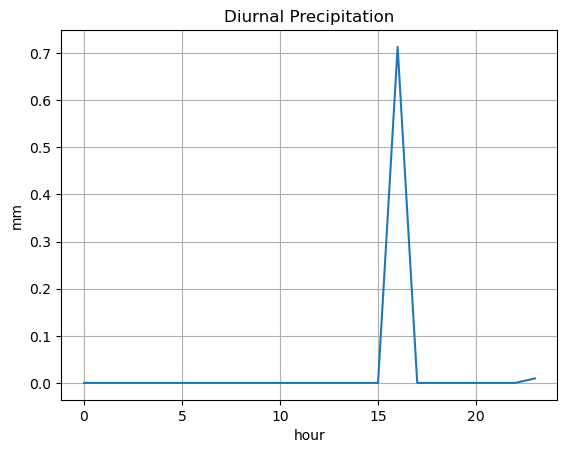

In [62]:
plt.plot(sample_2001_2002.iloc[3]['daily_precip'])

plt.ylabel("mm")

plt.xlabel("hour")

plt.grid()

plt.title('Diurnal Precipitation')

plt.show()

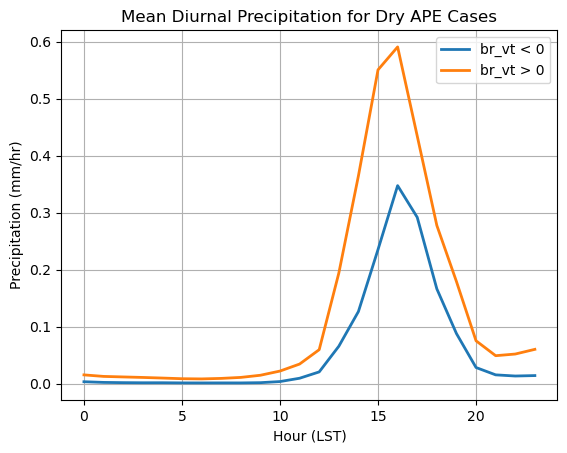

In [68]:
# --- Filters ---

neg_group = df_dry[df_dry['br_vt'] < 0]

pos_group = df_dry[df_dry['br_vt'] > 0]

# --- Convert list-like daily_precip into arrays and stack ---

neg_precip = np.stack(neg_group['daily_precip'].values)    # shape: (N_neg, 24)

pos_precip = np.stack(pos_group['daily_precip'].values)    # shape: (N_pos, 24)

# --- Mean diurnal precipitation for each group ---

neg_diurnal = np.mean(neg_precip, axis=0)   # shape (24,)

pos_diurnal = np.mean(pos_precip, axis=0)   # shape (24,)

hours = np.arange(len(neg_diurnal))

plt.plot(hours, neg_diurnal, label="br_vt < 0", linewidth=2)

plt.plot(hours, pos_diurnal, label="br_vt > 0", linewidth=2)

plt.xlabel("Hour (LST)")

plt.ylabel("Precipitation (mm/hr)")

plt.title("Mean Diurnal Precipitation for Dry APE Cases")

plt.legend()

plt.grid(True)

plt.show()

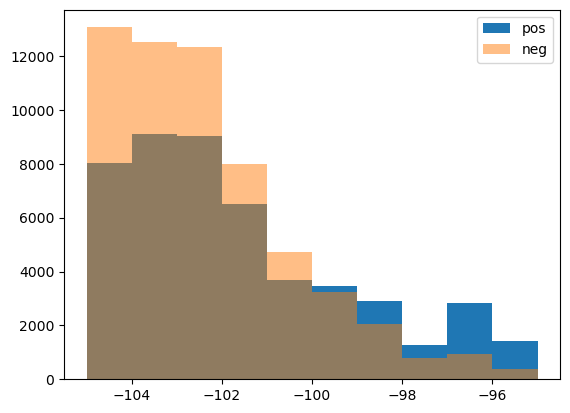

In [92]:
sub = df_dry

neg_group = sub[sub['br_vt'] < 0]

pos_group = sub[sub['br_vt'] > 0]

plt.hist(pos_group['longitude'], label='pos')

plt.hist(neg_group['longitude'], alpha=0.5, label='neg')

plt.legend()

plt.show()